In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 设置中文字体显示
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

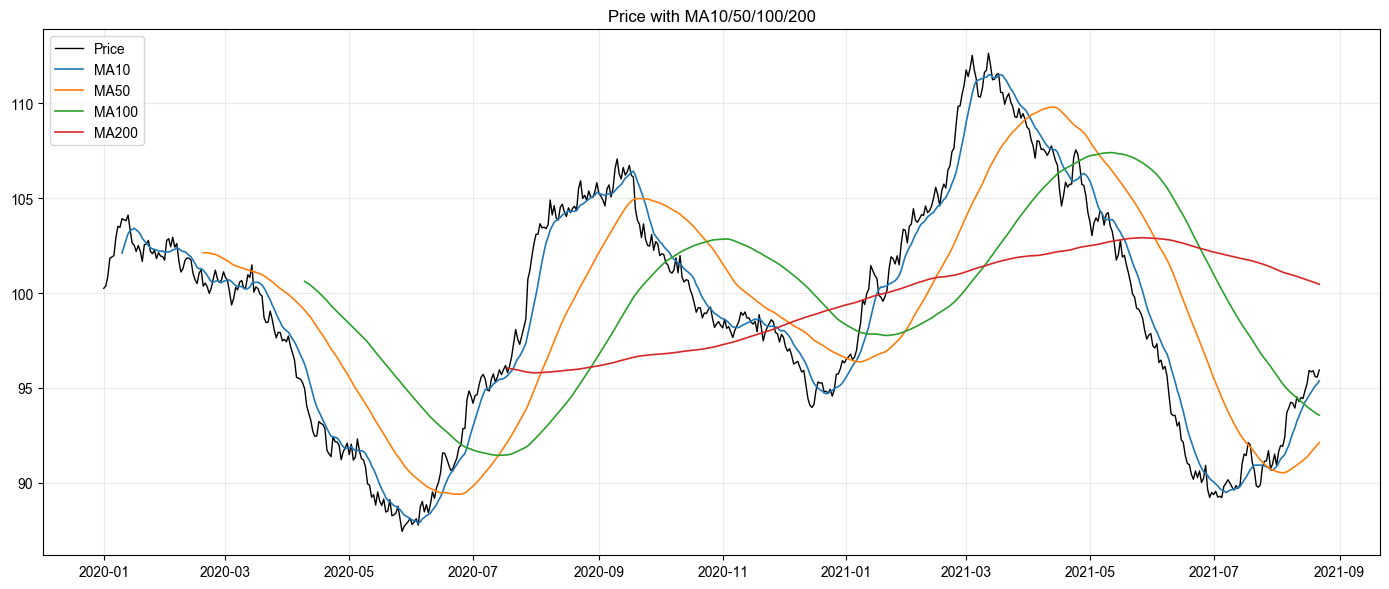

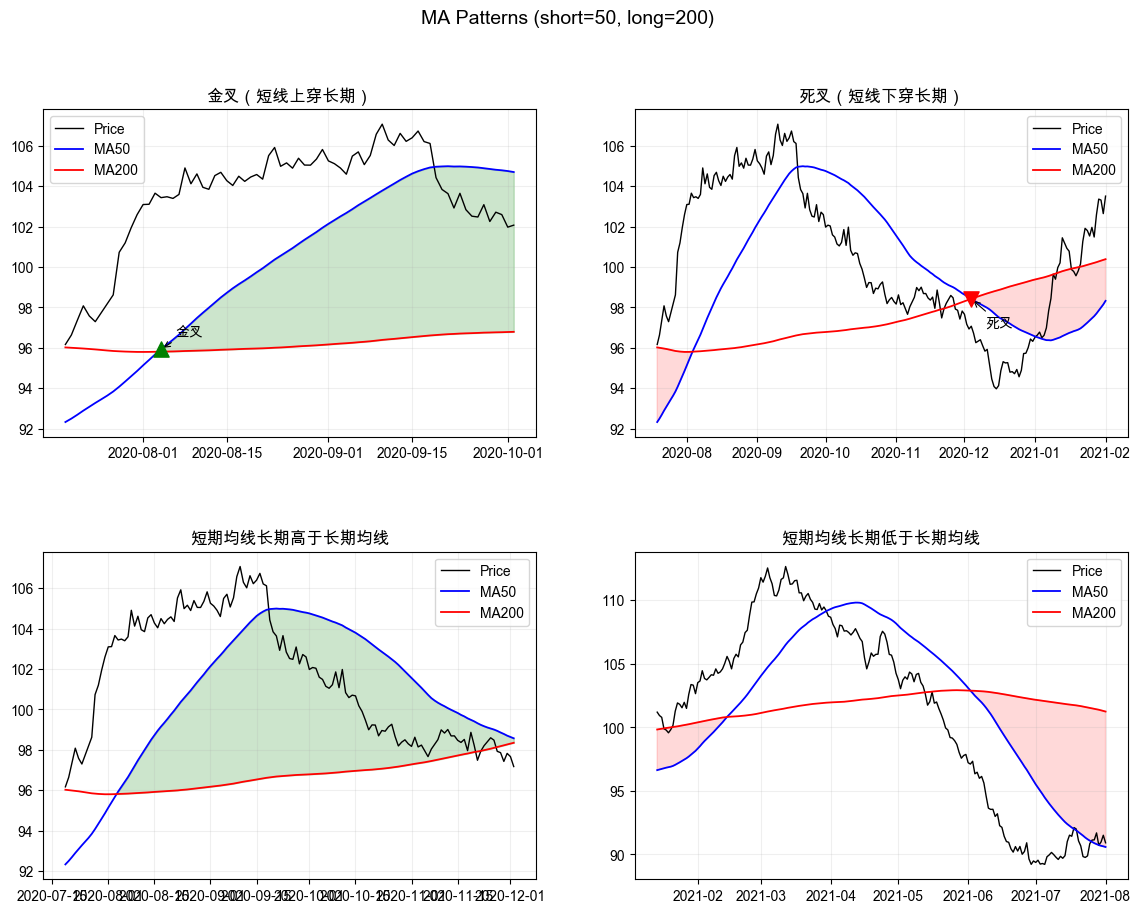

In [3]:
def plot_ma_and_examples(price: pd.Series,
                         short_window=50,
                         long_window=200,
                         extra_mas=(10,100),
                         win_len=120):
    """
    price: pd.Series (index最好为日期)
    short_window/long_window: 用于示例子图的短/长期均线（默认 50 / 200）
    extra_mas: 额外在主图上绘制的 MA 窗口（例如 10, 100）
    win_len: 子图窗口长度（天数）
    """
    price = price.dropna().copy()
    if price.empty:
        raise ValueError("price is empty after dropna()")
    
    # 确保有足够的数据计算长期均线
    if len(price) < long_window:
        print(f"警告：数据长度({len(price)})小于长期均线窗口({long_window})，长期均线可能无法正确计算")
    
    # 计算各均线
    ma = {}
    ma[10] = price.rolling(window=10).mean()
    ma[short_window] = price.rolling(window=short_window).mean()
    ma[100] = price.rolling(window=100).mean()
    ma[long_window] = price.rolling(window=long_window).mean()

    ma10, ma50, ma100, ma200 = ma[10], ma[short_window], ma[100], ma[long_window]

    # ---------- 主图： price + MA10/50/100/200 ----------
    fig_main, ax_main = plt.subplots(1,1, figsize=(14,6))
    ax_main.plot(price, label='Price', color='black', lw=1)
    ax_main.plot(ma10, label=f'MA{10}', lw=1.2)
    ax_main.plot(ma50, label=f'MA{short_window}', lw=1.2)
    ax_main.plot(ma100, label='MA100', lw=1.2)
    ax_main.plot(ma200, label=f'MA{long_window}', lw=1.2)
    ax_main.set_title(f'Price with MA{10}/{short_window}/100/{long_window}')
    ax_main.legend(loc='upper left')
    ax_main.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    # ---------- 准备交叉与持续段落检索 ----------
    short = ma50
    long = ma200
    
    # 确保均线数据有效（去除NaN）
    valid_data = ~(short.isna() | long.isna())
    short_valid = short[valid_data]
    long_valid = long[valid_data]
    
    # 交叉点计算（只在有效数据范围内）
    cross_up = (short_valid.shift(1) < long_valid.shift(1)) & (short_valid > long_valid)
    cross_down = (short_valid.shift(1) > long_valid.shift(1)) & (short_valid < long_valid)
    up_idx = list(cross_up[cross_up].index)
    down_idx = list(cross_down[cross_down].index)

    # 找出最长的短期>长期和短期<长期的连续段（只在有效数据范围内）
    cond = (short_valid > long_valid).astype(int)  # 1 表示短期 > 长期
    # group连续段
    groups = (cond != cond.shift(1)).cumsum()
    runs = []
    for g, grp in cond.groupby(groups):
        val = grp.iloc[0]  # 1 or 0
        runs.append({
            'is_high': bool(val),
            'start': grp.index[0],
            'end': grp.index[-1],
            'length': len(grp)
        })
    
    # 选择最长的 short>long 段与最长的 short<long 段
    high_runs = [r for r in runs if r['is_high']]
    low_runs = [r for r in runs if not r['is_high']]
    high_run = max(high_runs, key=lambda x: x['length']) if high_runs else None
    low_run = max(low_runs, key=lambda x: x['length']) if low_runs else None

    # 改进的窗口选择函数
    def make_window(center_idx, min_start_offset=long_window):
        """
        创建窗口，确保有足够的数据计算长期均线
        min_start_offset: 确保窗口开始位置有足够数据计算长期均线
        """
        idx = price.index
        try:
            pos = idx.get_loc(center_idx)
        except Exception:
            # fallback to middle of series
            pos = len(idx)//2
        
        # 确保窗口开始位置有足够数据计算长期均线
        start = max(min_start_offset, pos - win_len//2)
        end = min(len(idx), pos + win_len//2)
        
        # 如果窗口太小，调整到最小需要的长度
        if end - start < long_window:
            start = max(min_start_offset, end - long_window)
        
        return idx[start:end]

    # choose windows - 改进选择逻辑
    if up_idx:
        win_up = make_window(up_idx[0])
        up_point = up_idx[0]
    else:
        # 选择数据后半部分，确保有足够数据计算均线
        start_pos = max(long_window, len(price) - win_len)
        win_up = price.index[start_pos:]
        up_point = None

    if down_idx:
        win_down = make_window(down_idx[0])
        down_point = down_idx[0]
    else:
        # 选择数据后半部分
        start_pos = max(long_window, len(price) - win_len)
        win_down = price.index[start_pos:]
        down_point = None

    if high_run:
        # use middle of high run
        mid_pos = high_run['start'] if high_run['length'] <= win_len else \
                  price.index[price.index.get_loc(high_run['start']) + high_run['length']//2]
        win_high = make_window(mid_pos)
    else:
        # 选择数据后半部分
        start_pos = max(long_window, len(price) - win_len)
        win_high = price.index[start_pos:]

    if low_run:
        mid_pos = low_run['start'] if low_run['length'] <= win_len else \
                  price.index[price.index.get_loc(low_run['start']) + low_run['length']//2]
        win_low = make_window(mid_pos)
    else:
        # 选择数据后半部分
        start_pos = max(long_window, len(price) - win_len)
        win_low = price.index[start_pos:]

    # ---------- 画 2x2 子图：每个都包含 price + MA50 + MA200 ----------
    fig, axs = plt.subplots(2,2, figsize=(14,10))
    plt.subplots_adjust(hspace=0.35, wspace=0.2)

    # helper plot function - 改进版本
    def plot_window(ax, window_idx, title, mark_idx=None, fill_positive=False, fill_negative=False):
        # 确保窗口内有有效数据
        pr = price.loc[window_idx]
        s = short.loc[window_idx]
        l = long.loc[window_idx]
        
        # 检查数据有效性
        valid_mask = ~(s.isna() | l.isna())
        if not valid_mask.any():
            ax.text(0.5, 0.5, '数据不足，无法计算长期均线', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(title + " (数据不足)")
            return
        
        # 只在有效数据范围内绘图
        pr_valid = pr[valid_mask]
        s_valid = s[valid_mask]
        l_valid = l[valid_mask]
        
        ax.plot(pr_valid.index, pr_valid.values, label='Price', color='black', lw=1)
        ax.plot(s_valid.index, s_valid.values, label=f'MA{short_window}', color='blue', lw=1.3)
        ax.plot(l_valid.index, l_valid.values, label=f'MA{long_window}', color='red', lw=1.3)
        
        # 填充
        if fill_positive:
            ax.fill_between(s_valid.index, s_valid, l_valid, 
                           where=(s_valid > l_valid), interpolate=True, 
                           color='green', alpha=0.2)
        if fill_negative:
            ax.fill_between(s_valid.index, s_valid, l_valid, 
                           where=(s_valid < l_valid), interpolate=True, 
                           color='red', alpha=0.15)
        
        # 标注交叉点
        if mark_idx is not None and (mark_idx in pr_valid.index):
            y = s_valid.loc[mark_idx]
            ax.scatter([mark_idx], [y], marker='^' if fill_positive else 'v', 
                       color='green' if fill_positive else 'red', s=120, zorder=5)
            ax.annotate('金叉' if fill_positive else '死叉',
                        xy=(mark_idx, y),
                        xytext=(10, 10 if fill_positive else -20),
                        textcoords='offset points',
                        fontsize=10,
                        arrowprops=dict(arrowstyle='->', lw=0.8))
        
        ax.set_title(title)
        ax.grid(alpha=0.2)
        ax.legend()

    plot_window(axs[0,0], win_up, "金叉（短线上穿长期）", mark_idx=up_point, fill_positive=True)
    plot_window(axs[0,1], win_down, "死叉（短线下穿长期）", mark_idx=down_point, fill_negative=True)
    plot_window(axs[1,0], win_high, "短期均线长期高于长期均线", fill_positive=True)
    plot_window(axs[1,1], win_low, "短期均线长期低于长期均线", fill_negative=True)

    fig.suptitle(f'MA Patterns (short={short_window}, long={long_window})', fontsize=14)
    plt.show()

# ========== 使用方法 ==========
if __name__ == "__main__":
    # ---------- 测试/示例（生成更长的模拟数据以确保长期均线有效） ----------
    np.random.seed(42)
    days = 600  # 增加数据长度
    # 模拟更平滑的价格序列以更好演示均线形态
    t = np.linspace(0, 6*np.pi, days)
    price_sim = pd.Series(100 + np.sin(t)*6 + np.cumsum(np.random.randn(days)*0.5))
    price_sim.index = pd.date_range("2020-01-01", periods=days)
    # 运行画图
    plot_ma_and_examples(price_sim, short_window=50, long_window=200, win_len=120)